<a href="https://colab.research.google.com/github/Saisneha0209/Machine-Learning/blob/main/Stock_Market_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.metrics import accuracy_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('ztr.us.csv')
print(df)

            Date    Open    High     Low   Close  Volume  OpenInt
0     2005-02-25   9.823   9.842   9.823   9.842   65217        0
1     2005-02-28   9.842   9.858   9.823   9.842   91235        0
2     2005-03-01   9.823   9.858   9.805   9.823  163706        0
3     2005-03-02   9.823   9.858   9.823   9.842   54858        0
4     2005-03-03   9.823   9.858   9.823   9.858  101376        0
...          ...     ...     ...     ...     ...     ...      ...
3196  2017-11-06  13.360  13.499  13.321  13.489  142559        0
3197  2017-11-07  13.509  13.569  13.450  13.539  110820        0
3198  2017-11-08  13.509  13.543  13.410  13.460   78385        0
3199  2017-11-09  13.440  13.532  13.380  13.420   71868        0
3200  2017-11-10  13.450  13.530  13.310  13.380  121146        0

[3201 rows x 7 columns]


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
x = df[["Open", "High", "Low", "Volume", "Year", "Month", "Day"]]
y = df["Close"]

print(x)
print(y)

        Open    High     Low  Volume  Year  Month  Day
0      9.823   9.842   9.823   65217  2005      2   25
1      9.842   9.858   9.823   91235  2005      2   28
2      9.823   9.858   9.805  163706  2005      3    1
3      9.823   9.858   9.823   54858  2005      3    2
4      9.823   9.858   9.823  101376  2005      3    3
...      ...     ...     ...     ...   ...    ...  ...
3196  13.360  13.499  13.321  142559  2017     11    6
3197  13.509  13.569  13.450  110820  2017     11    7
3198  13.509  13.543  13.410   78385  2017     11    8
3199  13.440  13.532  13.380   71868  2017     11    9
3200  13.450  13.530  13.310  121146  2017     11   10

[3201 rows x 7 columns]
0        9.842
1        9.842
2        9.823
3        9.842
4        9.858
         ...  
3196    13.489
3197    13.539
3198    13.460
3199    13.420
3200    13.380
Name: Close, Length: 3201, dtype: float64


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
pred = model.predict(x_test)
user_input = np.array([[9.823,9.842,9.842,65217,2005,2,25]])
u_pred = model.predict(user_input)
print("Soo the predicted closing price is:", u_pred[0])

Soo the predicted closing price is: 9.842365355677677


In [5]:
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"R2 Score: {r2}")
print(f"Root Mean Squared Error: {rmse}")

R2 Score: 0.9986771366643913
Root Mean Squared Error: 0.05558488185491024


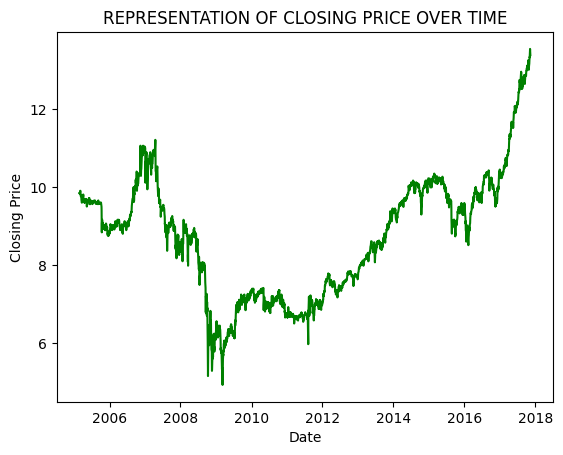

In [6]:
import matplotlib.pyplot as plt
plt.plot(df['Date'], df['Close'], color='green', label='Actual Close')
plt.title("REPRESENTATION OF CLOSING PRICE OVER TIME")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

In [7]:
df['Daily_Price'] = df['High'] - df['Low']
avg_price_per_year = df.groupby('Year')['Daily_Price'].mean()
print("Average Daily Price by Year:", avg_price_per_year)

Average Daily Price by Year: Year
2005    0.067201
2006    0.096612
2007    0.163939
2008    0.220567
2009    0.123288
2010    0.094233
2011    0.077172
2012    0.057400
2013    0.061693
2014    0.061067
2015    0.078094
2016    0.091952
2017    0.100560
Name: Daily_Price, dtype: float64


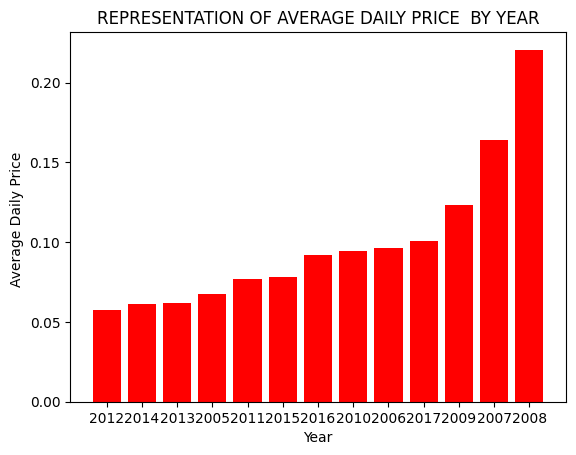

In [8]:
avg_price_per_year = avg_price_per_year.sort_values()

plt.bar(avg_price_per_year.index.astype(str) , avg_price_per_year, color='RED', label='Avg Daily Price')
plt.title("REPRESENTATION OF AVERAGE DAILY PRICE  BY YEAR")
plt.xlabel('Year')
plt.ylabel('Average Daily Price ')
plt.show()

In [9]:
max_volume_per_year = df.groupby('Year')['Volume'].max()
print("Maximum Volume by Year:")
print(max_volume_per_year)

Maximum Volume by Year:
Year
2005     440601
2006     474889
2007    1008326
2008    1253834
2009     443227
2010    2885813
2011    1728515
2012    1436680
2013     406630
2014     403230
2015     683073
2016     435523
2017     436889
Name: Volume, dtype: int64


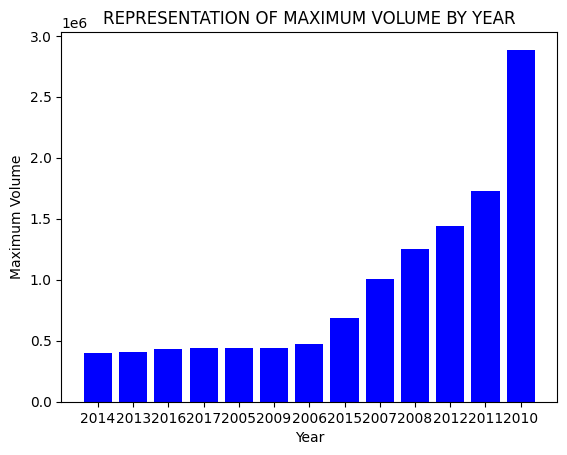

In [10]:
max_volume_per_year = max_volume_per_year.sort_values()
plt.bar(max_volume_per_year.index.astype(str), max_volume_per_year, color='BLUE', label='Max Volume')
plt.title("REPRESENTATION OF MAXIMUM VOLUME BY YEAR")
plt.xlabel('Year')
plt.ylabel('Maximum Volume')
plt.show()
#Scientific Notation!!

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

In [12]:
model={
       "Linear regression":LinearRegression(),
       "Decision Tree Regressor": DecisionTreeRegressor(),
       "Random Forest Regressor": RandomForestRegressor(),
       "Gradient Boosting Regressor": GradientBoostingRegressor(),
       "K Neighbors Regressor": KNeighborsRegressor()
}

user_input = np.array([[9.823,9.842,9.842,65217,2005,2,25]])
for name, model in model.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    user_pred = model.predict(user_input)
    print("\n=======================")
    print(name)
    print("Predicted Price:", user_pred)
    print("Here the mean absolute error:", mean_absolute_error(y_test, pred))
    print("Mean Squared Error:", mean_squared_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))


Linear regression
Predicted Price: [9.84236536]
Here the mean absolute error: 0.0274805625196074
Mean Squared Error: 0.00308967909082433
RMSE: 0.05558488185491024

Decision Tree Regressor
Predicted Price: [9.845]
Here the mean absolute error: 0.04250702028081118
Mean Squared Error: 0.00505120115444617
RMSE: 0.07107180280847089

Random Forest Regressor
Predicted Price: [9.83915]
Here the mean absolute error: 0.03199639781591283
Mean Squared Error: 0.0032926601230093724
RMSE: 0.057381705473167774

Gradient Boosting Regressor
Predicted Price: [9.86389934]
Here the mean absolute error: 0.03416501491444986
Mean Squared Error: 0.0030075201507821442
RMSE: 0.054840862053601454

K Neighbors Regressor
Predicted Price: [9.95002]
Here the mean absolute error: 1.164525647425897
Mean Squared Error: 2.2712971112405618
RMSE: 1.5070823173405499
